# Chapter 3: Oriented Intersection Theory

**Source Span.** `Differential Topology.pdf` printed pages `94-150`, with section landmarks on motivation, orientation, oriented intersection number, Lefschetz fixed-point theory, vector fields and the Poincare-Hopf theorem, the Hopf degree theorem, and Euler characteristic through triangulations.

**Chapter Goal.** Upgrade mod two counting into signed counting. Orientation turns a local crossing into `+1` or `-1`; signed intersection numbers become homotopy invariants; fixed points acquire local indices; vector fields encode Euler characteristic through their zeros; and degree becomes the common language connecting maps, intersections, and global topology.

The previous chapter showed that parity can survive deformation. This chapter explains what extra information is available when orientation is present. A sign is not an ornament attached after the fact. It is a determinant comparison between ordered tangent bases. Once signs are assigned consistently, several different-looking constructions become versions of the same invariant: oriented intersection number, local Lefschetz number, index of a vector-field zero, degree of a map, and Euler characteristic. The notebook therefore centers its visuals on frames, determinants, and sums of local contributions.

The source is used for structure and terminology only. The models below are original, small, and computationally explicit so that the notebook can be read without the textbook open.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib, save_plotly_html

UNIT_KEY = "chapter-03-oriented-intersection-theory"
UNIT_TITLE = "Oriented Intersection Theory"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
TRACKED_ARTIFACTS = []
np.set_printoptions(precision=4, suppress=True)
print(f"Book root: {BOOK_ROOT}")


Book root: D:\Geometry\Differential-Topology


## Visual Storyboard

1. **Orientation frame comparator.** Ordered bases in the plane are drawn as arrows. The determinant decides whether a frame agrees with the ambient orientation or reverses it.
2. **Signed intersection lab.** Two oriented one-manifolds in the plane meet in finitely many transverse points. Each point receives a sign from the ordered pair of tangent directions, and the notebook sums those signs.
3. **Lefschetz and degree on the circle.** The map `z -> z^d` supplies a compact model where degree, fixed-point index, and the sign of `1-df` can be inspected directly.
4. **Vector fields and Poincare-Hopf.** Local vector-field patterns around isolated zeros are plotted and their winding indices are computed. The sum is compared with Euler characteristic examples.
5. **Euler characteristic and triangulation table.** Cell counts for sphere and torus models record the invariant that the index theorem recovers.

## Library Routing

| Concept | Representation | Library | Why this route is used | Check |
| --- | --- | --- | --- | --- |
| Orientation | Ordered frames with determinant signs | Matplotlib + SymPy | Signs are determinant comparisons, so exact arithmetic is helpful | determinant sign matches label |
| Oriented intersections | Transverse curve crossings with tangent arrows | Matplotlib + NumPy | Local signs must be visible at each crossing | signed sum equals stored intersection number |
| Lefschetz/degree | Circle map `z^d` and fixed-point table | Plotly + SymPy | Degree is angular and benefits from a circle visualization | sum of local indices equals `1-d` in model cases |
| Poincare-Hopf/Euler characteristic | Vector-field index panels and cell-count table | Matplotlib + CSV/JSON | The theorem compares local winding to global cell counts | index sums equal example Euler characteristics |


## Orientation As A Determinant Test

An orientation of a real vector space is a consistent choice of which ordered bases count as positive. In a chart, an ordered basis is represented by a matrix whose columns are the basis vectors. The sign of its determinant tells whether it agrees with the standard orientation. On a manifold, orientations must be transported through compatible charts, so the determinant of transition maps must remain positive where the oriented atlas overlaps.

The figure below shows three frames. The first agrees with the standard orientation of the plane. The second reverses orientation by swapping the order of the basis vectors. The third is skew but still positive because its determinant is positive. This is the exact local mechanism used later for intersection signs, boundary orientations, and preimage orientations. If a theorem seems to attach mysterious signs to points, this is the microscope: order the tangent directions, compare to the ambient orientation, and read the determinant.


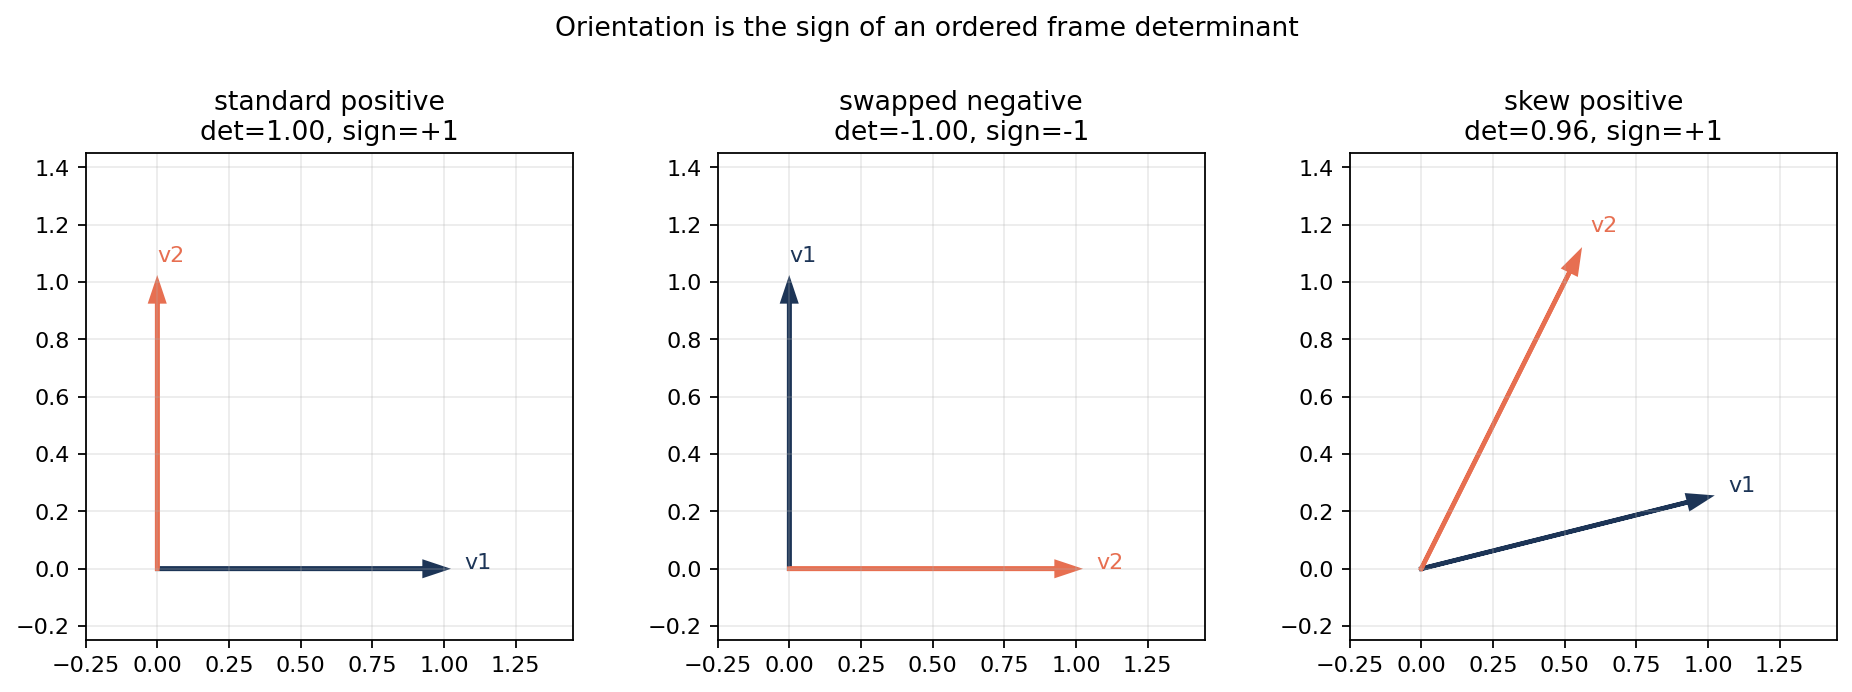

[{'frame': 'standard positive', 'determinant': 1.0, 'orientation_sign': 1},
 {'frame': 'swapped negative', 'determinant': -1.0, 'orientation_sign': -1},
 {'frame': 'skew positive', 'determinant': 0.9625, 'orientation_sign': 1}]

In [2]:
frames = [
    (np.array([[1.0, 0.0], [0.0, 1.0]]), "standard positive"),
    (np.array([[0.0, 1.0], [1.0, 0.0]]), "swapped negative"),
    (np.array([[1.0, 0.55], [0.25, 1.1]]), "skew positive"),
]
frame_rows = []
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (basis, label) in zip(axes, frames):
    det = float(np.linalg.det(basis))
    sign = 1 if det > 0 else -1
    colors = ["#1d3557", "#e76f51"]
    for j in range(2):
        ax.arrow(0, 0, basis[0, j], basis[1, j], head_width=0.045, length_includes_head=True, color=colors[j], linewidth=2)
        ax.text(1.07*basis[0, j], 1.07*basis[1, j], f"v{j+1}", color=colors[j])
    ax.set_title(f"{label}\ndet={det:.2f}, sign={sign:+d}")
    ax.set_xlim(-0.25, 1.45)
    ax.set_ylim(-0.25, 1.45)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    frame_rows.append({"frame": label, "determinant": round(det, 6), "orientation_sign": sign})
fig.suptitle("Orientation is the sign of an ordered frame determinant", y=1.03)
fig.tight_layout()
frame_path = save_matplotlib(fig, FIGURES / "orientation-frame-determinant-comparator.png")
plt.close(fig)
frame_csv = save_csv(frame_rows, TABLES / "orientation-frame-determinant-comparator.csv")
frame_json = save_json({"rows": frame_rows}, CHECKS / "orientation-frame-determinant-comparator.json")
TRACKED_ARTIFACTS.extend([frame_path, frame_csv, frame_json])
display_artifact(frame_path, width=840)
frame_rows


## Oriented Intersection Number

For two oriented submanifolds of complementary dimensions, a transverse intersection point receives a local sign. In the plane, two oriented curves meet positively when the ordered pair `(tangent to X, tangent to Z)` agrees with the plane orientation, and negatively when it reverses that orientation. Summing these local signs produces an oriented intersection number. Unlike a bare count, the signed sum can cancel, and that cancellation is meaningful: it records algebraic intersection, not just how many dots appear in a drawing.

The model below uses a horizontal oriented curve and a wavy oriented curve. They meet transversely at two points, with opposite local signs. The ordinary count is two, the mod two count is zero, and the oriented sum is also zero for a more refined reason: one crossing is positive and the other is negative. The cell saves the tangent vectors and determinant signs so the result can be audited numerically.


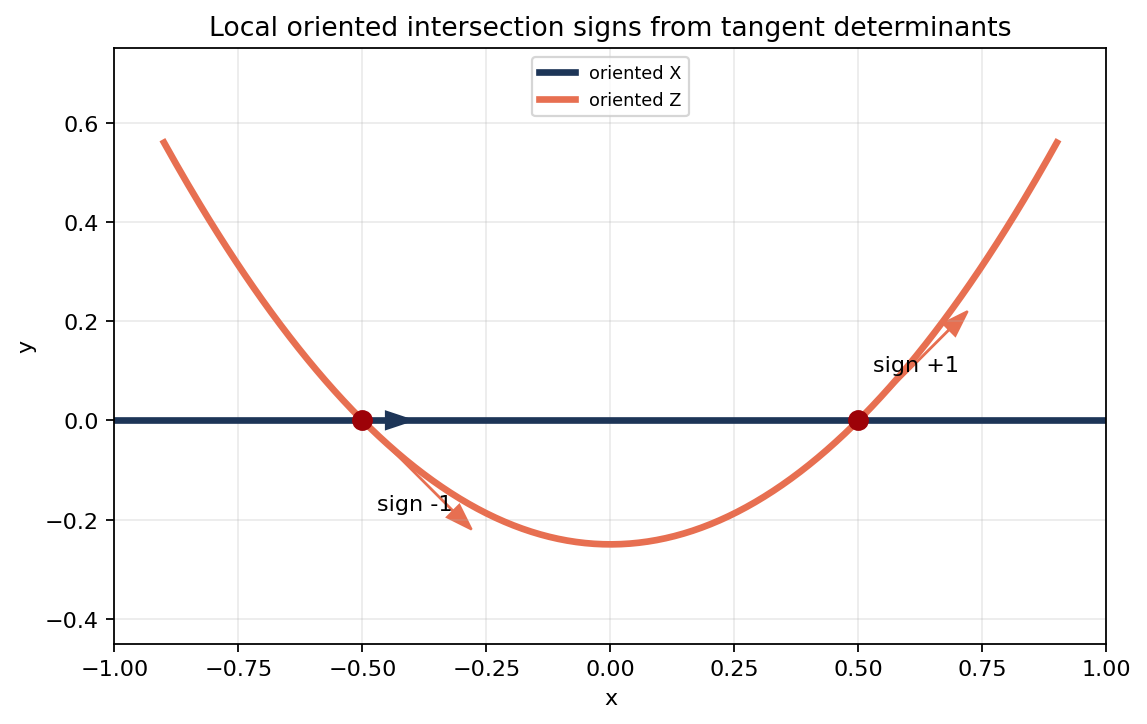

{'intersection_number': 0,
 'rows': [{'point': '(-0.50, 0.00)',
   'tangent_order': 'X tangent then Z tangent',
   'determinant': -1.0,
   'local_sign': -1},
  {'point': '(0.50, 0.00)',
   'tangent_order': 'X tangent then Z tangent',
   'determinant': 1.0,
   'local_sign': 1}]}

In [3]:
# X is the oriented x-axis segment. Z is y = x^2 - 0.25, oriented left-to-right.
xs = np.linspace(-0.9, 0.9, 300)
z_y = xs**2 - 0.25
roots = [-0.5, 0.5]
intersection_rows = []
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color="#1d3557", lw=3, label="oriented X")
ax.arrow(-0.75, 0, 0.35, 0, head_width=0.035, color="#1d3557", length_includes_head=True)
ax.plot(xs, z_y, color="#e76f51", lw=3, label="oriented Z")
for r in roots:
    tangent_x = np.array([1.0, 0.0])
    tangent_z = np.array([1.0, 2*r])
    det = float(np.linalg.det(np.column_stack([tangent_x, tangent_z])))
    sign = 1 if det > 0 else -1
    intersection_rows.append({"point": f"({r:.2f}, 0.00)", "tangent_order": "X tangent then Z tangent", "determinant": round(det, 6), "local_sign": sign})
    ax.scatter([r], [0], color="#9d0208", s=70, zorder=4)
    ax.arrow(r, 0, 0.22*tangent_z[0], 0.22*tangent_z[1], head_width=0.035, color="#e76f51", length_includes_head=True)
    ax.text(r + 0.03, 0.10 if sign > 0 else -0.18, f"sign {sign:+d}")
ax.set_title("Local oriented intersection signs from tangent determinants")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(-1.0, 1.0)
ax.set_ylim(-0.45, 0.75)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="upper center", fontsize=8)
intersect_path = save_matplotlib(fig, FIGURES / "oriented-intersection-local-signs.png")
plt.close(fig)
intersection_number = sum(row["local_sign"] for row in intersection_rows)
intersect_csv = save_csv(intersection_rows, TABLES / "oriented-intersection-local-signs.csv")
intersect_json = save_json({"rows": intersection_rows, "ordinary_count": len(intersection_rows), "oriented_intersection_number": intersection_number}, CHECKS / "oriented-intersection-local-signs.json")
TRACKED_ARTIFACTS.extend([intersect_path, intersect_csv, intersect_json])
display_artifact(intersect_path, width=760)
{"intersection_number": intersection_number, "rows": intersection_rows}


## Lefschetz, Degree, And Local Fixed-Point Index

The Lefschetz section turns a fixed point into an intersection problem: a fixed point of `f` is an intersection of the graph of `f` with the diagonal. When the intersection is transverse, the local contribution is a sign determined by `I-df`. On the circle, the degree-`d` map `z -> z^d` gives a transparent model. Its global Lefschetz number is `1-d`, and the local fixed-point index at a transverse fixed point matches the sign of `1-d` in simple cases.

This model is intentionally modest. It does not replace the theorem for arbitrary manifolds, but it lets us inspect the three ingredients that recur later: a global topological invariant (degree), a local linearization (`df` on the tangent line), and a signed fixed-point contribution. The same pattern appears again in vector-field index and Poincare-Hopf.


In [4]:
degrees = [0, 2, 3]
lefschetz_rows = []
fig = go.Figure()
unit = np.linspace(0, 2*np.pi, 500)
fig.add_trace(go.Scatter(x=np.cos(unit), y=np.sin(unit), mode="lines", line=dict(color="#444444", width=1), name="S1"))
for d in degrees:
    if d == 0:
        fixed_angles = [0.0]
        derivative_on_tangent = 0.0
    else:
        # z^d=z gives (d-1)theta = 2*pi*n.
        fixed_angles = [2*np.pi*n/(d-1) for n in range(d-1)]
        derivative_on_tangent = float(d)
    local_index = 1 if (1 - derivative_on_tangent) > 0 else -1
    total_index = local_index * len(fixed_angles)
    lefschetz = 1 - d
    lefschetz_rows.append({"degree": d, "fixed_point_count": len(fixed_angles), "local_index_each": local_index, "sum_local_indices": total_index, "lefschetz_1_minus_degree": lefschetz})
    fig.add_trace(go.Scatter(x=[np.cos(a) for a in fixed_angles], y=[np.sin(a) for a in fixed_angles], mode="markers+text", marker=dict(size=10), text=[f"d={d}" for _ in fixed_angles], textposition="top center", name=f"fixed points d={d}"))
fig.update_layout(title="Circle maps: fixed points and Lefschetz number 1-d", xaxis_title="x", yaxis_title="y", width=700, height=620, yaxis_scaleanchor="x")
lefschetz_html = save_plotly_html(fig, HTML / "lefschetz-degree-fixed-points-circle.html")
lefschetz_csv = save_csv(lefschetz_rows, TABLES / "lefschetz-degree-fixed-points-circle.csv")
lefschetz_json = save_json({"rows": lefschetz_rows}, CHECKS / "lefschetz-degree-fixed-points-circle.json")
TRACKED_ARTIFACTS.extend([lefschetz_html, lefschetz_csv, lefschetz_json])
display_artifact(lefschetz_html, width=760, height=620)
lefschetz_rows


D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


[{'degree': 0,
  'fixed_point_count': 1,
  'local_index_each': 1,
  'sum_local_indices': 1,
  'lefschetz_1_minus_degree': 1},
 {'degree': 2,
  'fixed_point_count': 1,
  'local_index_each': -1,
  'sum_local_indices': -1,
  'lefschetz_1_minus_degree': -1},
 {'degree': 3,
  'fixed_point_count': 2,
  'local_index_each': -1,
  'sum_local_indices': -2,
  'lefschetz_1_minus_degree': -2}]

## Vector Fields, Index, Poincare-Hopf, And Euler Characteristic

A vector field near an isolated zero determines a map from a small circle around the zero to the unit circle: take each nearby vector and normalize it. The winding number of that normalized vector is the local index. The Poincare-Hopf theorem says that, on a compact oriented manifold, the sum of these local indices equals the Euler characteristic. This is one of the chapter's central bridges from local differential data to global topology.

The next panels show three local models: a source of index `+1`, a saddle of index `-1`, and a rotation field of index `+1`. The computation unwraps the vector angle around a circle and records the winding. A separate table compares model manifolds: the sphere can carry two `+1` zeros, matching Euler characteristic `2`; the torus can carry a nowhere-zero field, matching Euler characteristic `0`. The exact fields in the picture are planar local models, while the theorem tells how such local contributions must add up globally.


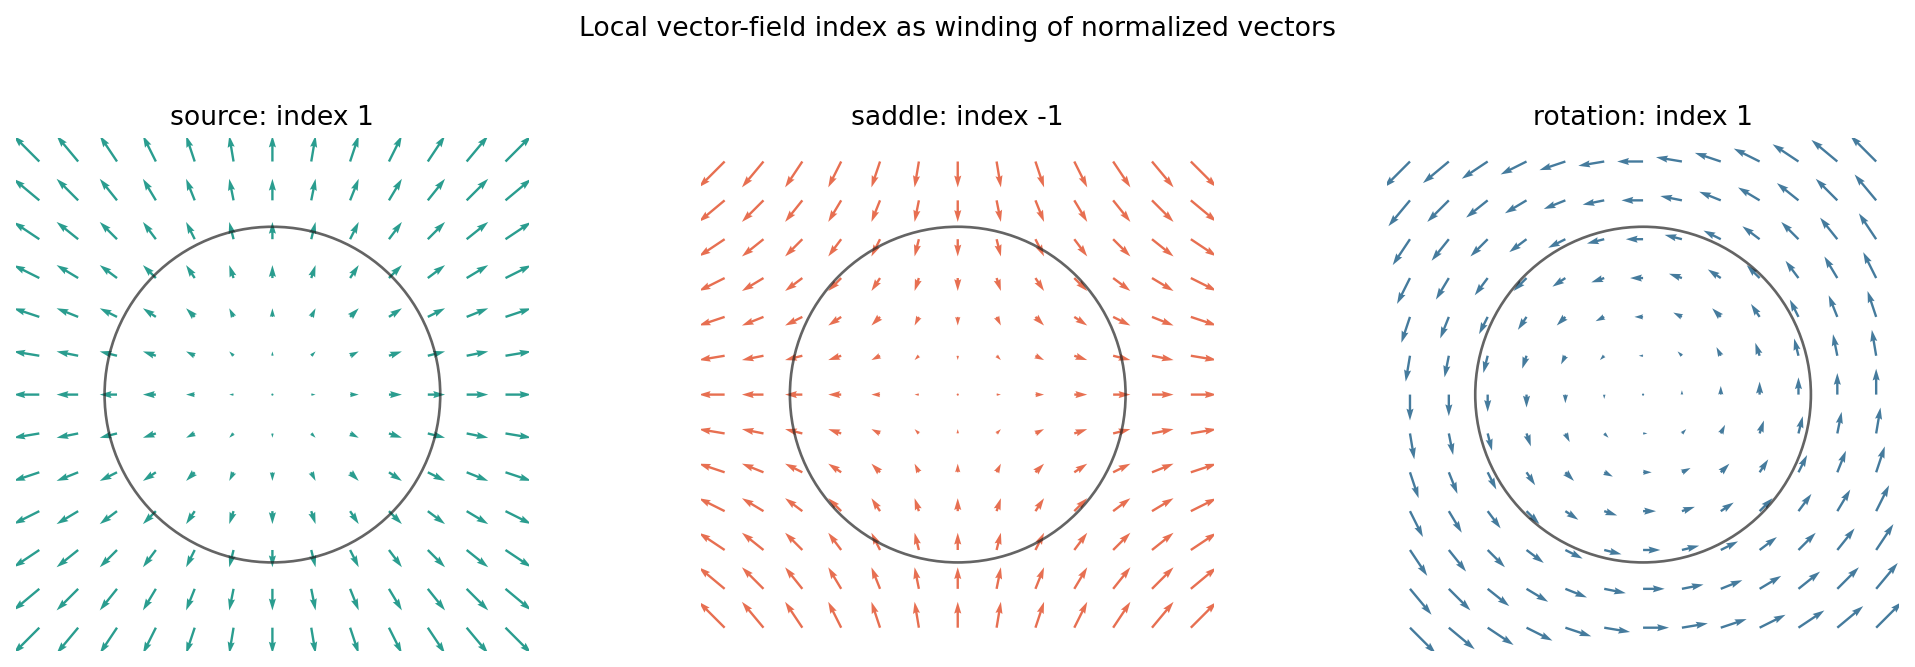

[{'field': 'source',
  'matrix': [[1.0, 0.0], [0.0, 1.0]],
  'computed_index': 1.0,
  'integer_index': 1},
 {'field': 'saddle',
  'matrix': [[1.0, 0.0], [0.0, -1.0]],
  'computed_index': -1.0,
  'integer_index': -1},
 {'field': 'rotation',
  'matrix': [[0.0, -1.0], [1.0, 0.0]],
  'computed_index': 1.0,
  'integer_index': 1}]

In [5]:
def vector_index(A, samples=720):
    th = np.linspace(0, 2*np.pi, samples, endpoint=True)
    pts = np.column_stack([np.cos(th), np.sin(th)])
    vec = pts @ A.T
    angles = np.unwrap(np.arctan2(vec[:, 1], vec[:, 0]))
    return float((angles[-1] - angles[0]) / (2*np.pi))

fields = [
    (np.array([[1.0, 0.0], [0.0, 1.0]]), "source", "#2a9d8f"),
    (np.array([[1.0, 0.0], [0.0, -1.0]]), "saddle", "#e76f51"),
    (np.array([[0.0, -1.0], [1.0, 0.0]]), "rotation", "#457b9d"),
]
field_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
grid = np.linspace(-1, 1, 13)
X, Y = np.meshgrid(grid, grid)
points = np.column_stack([X.ravel(), Y.ravel()])
for ax, (A, name, color) in zip(axes, fields):
    V = points @ A.T
    U = V[:, 0].reshape(X.shape)
    W = V[:, 1].reshape(Y.shape)
    ax.quiver(X, Y, U, W, color=color, angles="xy", scale_units="xy", scale=9)
    circle = plt.Circle((0, 0), 0.72, fill=False, color="#222222", lw=1.2, alpha=0.7)
    ax.add_patch(circle)
    idx = vector_index(A)
    field_rows.append({"field": name, "matrix": A.tolist(), "computed_index": round(idx, 6), "integer_index": int(round(idx))})
    ax.set_title(f"{name}: index {idx:.0f}")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.axis("off")
fig.suptitle("Local vector-field index as winding of normalized vectors", y=1.03)
fig.tight_layout()
field_path = save_matplotlib(fig, FIGURES / "vector-field-local-index-models.png")
plt.close(fig)
field_csv = save_csv(field_rows, TABLES / "vector-field-local-index-models.csv")
field_json = save_json({"rows": field_rows}, CHECKS / "vector-field-local-index-models.json")
TRACKED_ARTIFACTS.extend([field_path, field_csv, field_json])
display_artifact(field_path, width=860)
field_rows


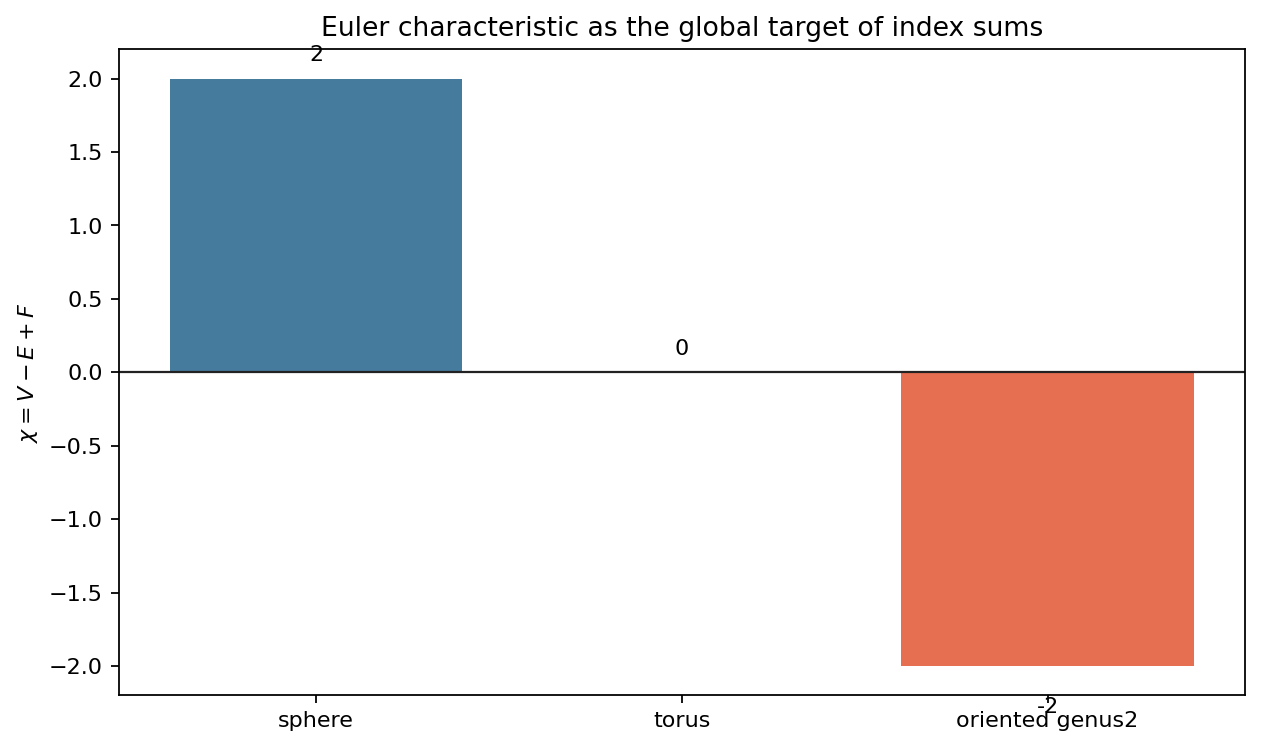

[{'space': 'sphere tetrahedral triangulation',
  'vertices': 4,
  'edges': 6,
  'faces': 4,
  'euler_characteristic': 2,
  'index_model': '+1 + +1'},
 {'space': 'torus square cell decomposition',
  'vertices': 1,
  'edges': 2,
  'faces': 1,
  'euler_characteristic': 0,
  'index_model': 'nowhere-zero field'},
 {'space': 'oriented surface genus 2',
  'vertices': 1,
  'edges': 4,
  'faces': 1,
  'euler_characteristic': -2,
  'index_model': 'total index -2'}]

In [6]:
euler_rows = [
    {"space": "sphere tetrahedral triangulation", "vertices": 4, "edges": 6, "faces": 4, "euler_characteristic": 4-6+4, "index_model": "+1 + +1"},
    {"space": "torus square cell decomposition", "vertices": 1, "edges": 2, "faces": 1, "euler_characteristic": 1-2+1, "index_model": "nowhere-zero field"},
    {"space": "oriented surface genus 2", "vertices": 1, "edges": 4, "faces": 1, "euler_characteristic": 1-4+1, "index_model": "total index -2"},
]
euler_csv = save_csv(euler_rows, TABLES / "euler-characteristic-index-comparison.csv")
euler_json = save_json({"rows": euler_rows}, CHECKS / "euler-characteristic-index-comparison.json")
TRACKED_ARTIFACTS.extend([euler_csv, euler_json])

fig, ax = plt.subplots(figsize=(8, 4.8))
spaces = [row["space"].split()[0] if row["space"].startswith("sphere") else row["space"].split()[0] + (" genus2" if "genus" in row["space"] else "") for row in euler_rows]
chis = [row["euler_characteristic"] for row in euler_rows]
ax.bar(spaces, chis, color=["#457b9d", "#2a9d8f", "#e76f51"])
ax.axhline(0, color="#222222", lw=1)
for i, chi in enumerate(chis):
    ax.text(i, chi + (0.12 if chi >= 0 else -0.32), str(chi), ha="center")
ax.set_ylabel(r"$\chi = V-E+F$")
ax.set_title("Euler characteristic as the global target of index sums")
fig.tight_layout()
euler_path = save_matplotlib(fig, FIGURES / "euler-characteristic-index-comparison.png")
plt.close(fig)
TRACKED_ARTIFACTS.append(euler_path)
display_artifact(euler_path, width=720)
euler_rows


## Applied Lab: Follow The Sign

The chapter becomes much easier to navigate if every construction is reduced to one question: what determinant, degree, or winding number supplies the sign? For oriented intersections, the sign comes from ordering tangent bases. For a fixed point, the sign comes from the linearization of the graph-diagonal intersection, represented in the circle model by `1-df`. For a vector-field zero, the sign and magnitude are encoded by the winding of the normalized field around a small loop. For Euler characteristic, the global value can be counted by cells or recovered as an index sum.

These are not separate tricks. They are manifestations of a single strategy: turn local differential information into an integer and prove that the integer survives deformation. The saved artifacts let you inspect the local input and the global output side by side.


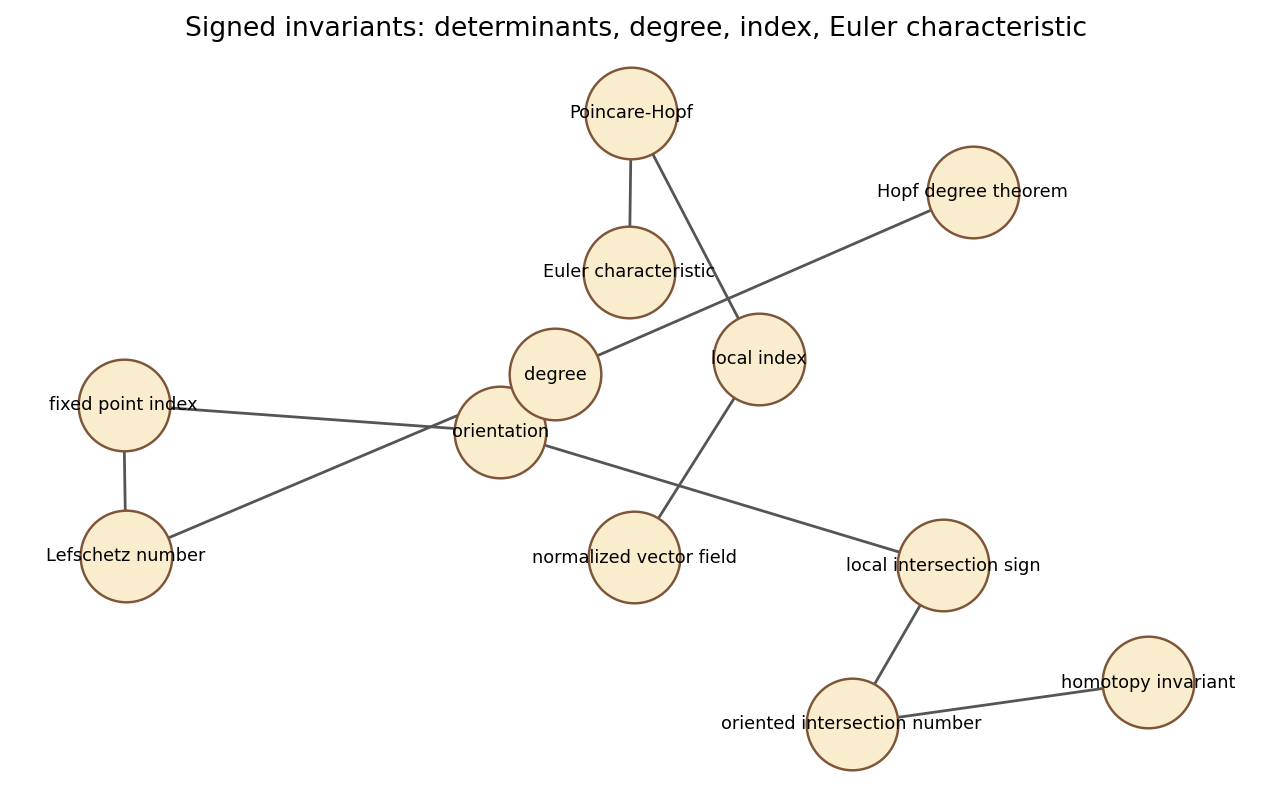

{'nodes': 12, 'edges': 10, 'acyclic': True}

In [7]:
G = nx.DiGraph()
edges = [
    ("orientation", "local intersection sign"),
    ("local intersection sign", "oriented intersection number"),
    ("oriented intersection number", "homotopy invariant"),
    ("orientation", "fixed point index"),
    ("fixed point index", "Lefschetz number"),
    ("degree", "Lefschetz number"),
    ("normalized vector field", "local index"),
    ("local index", "Poincare-Hopf"),
    ("Euler characteristic", "Poincare-Hopf"),
    ("degree", "Hopf degree theorem"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=31, k=0.85)
fig, ax = plt.subplots(figsize=(10, 6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", edge_color="#555555", width=1.25)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#faedcd", edgecolors="#7f5539", linewidths=1.1, node_size=1700)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Signed invariants: determinants, degree, index, Euler characteristic")
ax.axis("off")
dep_path = save_matplotlib(fig, FIGURES / "signed-invariant-dependency-map.png")
plt.close(fig)
dep_json = save_json({"nodes": list(G.nodes), "edges": edges, "acyclic": nx.is_directed_acyclic_graph(G)}, CHECKS / "signed-invariant-dependency-map.json")
TRACKED_ARTIFACTS.extend([dep_path, dep_json])
display_artifact(dep_path, width=780)
{"nodes": G.number_of_nodes(), "edges": G.number_of_edges(), "acyclic": nx.is_directed_acyclic_graph(G)}


In [8]:
assert frame_rows[0]["orientation_sign"] == 1
assert frame_rows[1]["orientation_sign"] == -1
assert intersection_number == 0
assert all(row["sum_local_indices"] == row["lefschetz_1_minus_degree"] for row in lefschetz_rows)
assert {row["field"]: row["integer_index"] for row in field_rows}["source"] == 1
assert {row["field"]: row["integer_index"] for row in field_rows}["saddle"] == -1
assert euler_rows[0]["euler_characteristic"] == 2
assert euler_rows[1]["euler_characteristic"] == 0
assert_artifacts(TRACKED_ARTIFACTS, min_bytes=80)
final_sanity = {
    "unit": UNIT_KEY,
    "tracked_artifacts": len(TRACKED_ARTIFACTS),
    "core_checks": ["orientation determinant signs", "oriented intersection sum", "Lefschetz equals 1-degree in circle models", "vector index and Euler characteristic examples"],
}
final_sanity


{'unit': 'chapter-03-oriented-intersection-theory',
 'tracked_artifacts': 17,
 'core_checks': ['orientation determinant signs',
  'oriented intersection sum',
  'Lefschetz equals 1-degree in circle models',
  'vector index and Euler characteristic examples']}

## Takeaways

Orientation refines counting. A local sign is a determinant comparison, and signed sums turn geometric events into deformation-resistant integers. Oriented intersection number, Lefschetz index, vector-field index, degree, and Euler characteristic are linked by this shared mechanism. The chapter's major theorems should be read as conversion rules: local tangent data becomes signs, signs become integer invariants, and those invariants constrain maps and vector fields on compact manifolds.

When a later notebook mentions degree or index, return to the same inspection routine: identify the local model, compute the determinant or winding number, and compare the local sum with the global invariant.
